In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", DeprecationWarning)


In [2]:
def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def load(agent_path, device='cuda'):
    agent, step = load_agent(agent_path)
    # agent = init_agent(configs[task][id])
    agent.device = device
    agent.wm.device = device
    agent.wm.rssm.device = device
    agent.wm.rssm._cell.device = device
    agent.is_finetune = True
    agent.cfg.agent.only_expl_during_training = False
    # if id == "5":
    #     agent._shape_skill_latent = 32 * 48
    return agent

# load relevant models
from pathlib import Path
from collections import defaultdict

models = defaultdict(list)

benchmark2agent = {"1": "dreamer", "2": "skill_dreamer", "3": "dreamer", "4": "lexa", "5": "skill_focus", "7": "focus"}
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw"}

base_path = Path("/mnt/public/projects/mazpie/")
tasks = ["reacher_easy", "CustomLift"]#, "shelf-place"]

expl_dataset = "expl_focus"
vis_targets = [True, False]
vis_target_str = lambda x: "_vis_target" if x else ""
distance_modes = ["cosine", "temporal"]

snapshot = "snapshot_250000"
seeds = [1, 2, 3]


In [3]:
# TEST DIRECTORIES GENERATION

# from os import listdir
# from os.path import isfile, join
# import os
# import random
# import shutil
# # Automate the process of test episodes collections, get 100 random episodes
# envs = ["shelf-place", "bin-picking"]

# for env in envs:
#     dir = f"/mnt/home/datasets/{env}/focus"
#     save_dir = f"/mnt/home/datasets/{env}/test_episodes"
    
#     if not os.path.exists(save_dir):
#         os.makedirs(save_dir)
    
#     all_files = [f for f in listdir(dir) if isfile(join(dir, f))]
    
#     files = random.sample(all_files, 100)
#     for file in files:
#         shutil.copy2(f"{dir}/{file}", f"{save_dir}/{file}") 

In [3]:
# LOAD TEST EPISODES
from env.utils import obs_specs
from dm_env import specs
from os import listdir
from os.path import isfile, join

episodes = {}

for task in tasks:
    for vis_target in vis_targets:
        if task not in ["reacher_easy", "reacher_hard"] and vis_target:
                continue
        episodes[f"{task}{vis_target_str(vis_target)}"] = []
        dataset_dir = f"/mnt/home/datasets/{task}/test_episodes{vis_target_str(vis_target)}"
        all_files = [f for f in listdir(dataset_dir) if isfile(join(dataset_dir, f))]
        for file in all_files:
            filename = Path(f"{dataset_dir}/{file}")
            with filename.open("rb") as f:
                episode = np.load(f)
                episode = {k: episode[k] for k in episode.keys()}
                episode["is_terminal"] = episode["discount"] == 0
                episode["is_first"] = np.zeros(len(episode["action"]), bool)
                episode["is_first"][0] = True
                episode = {
                        k: torch.as_tensor(np.copy(v), device="cuda:0").unsqueeze(0)
                        for k, v in episode.items()
                    }
                episodes[f"{task}{vis_target_str(vis_target)}"].append(episode)

In [4]:
from scipy import ndimage
import matplotlib.pyplot as plt
from tqdm import tqdm

agent_state = None

recon_error_metrics = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
target_indices = {"reacher_easy": [2,4], "reacher_hard": [2,4], "CustomLift": [-3, -1], "shelf-place": [-3, -1]}

num_episodes = 10
seeds = 1

def det(t):
    return t.detach().cpu().numpy()

def mean_std(t):
    if isinstance(t, torch.Tensor):
        t = det(t)
    
    mean = np.mean(t, axis=tuple(np.arange(1, len(t.shape))))
    std = np.std(t, axis=tuple(np.arange(1, len(t.shape))))
    
    # mean = np.nanmean(np.where(np.isclose(t,0, atol=1e-2), np.nan, t), axis=tuple(np.arange(2, len(t.shape)))) # TODO some values are set to nan, might be an issue with the denominator, need to be at least at 1
    # std = np.nanstd(np.where(np.isclose(t,0, atol=1e-2), np.nan, t), ddof=1, axis=tuple(np.arange(2, len(t.shape))))
    # stderr = std / np.sqrt(np.prod(t.shape[2:]) - np.isnan(np.where(np.isclose(t,0, atol=1e-2), np.nan, t)).sum(axis=tuple(np.arange(2, len(t.shape)))))
    return mean.mean(), std.mean() #, stderr.mean()

def merge_rgb_layers(data, seg):
    merged = torch.zeros((list(data.shape)[:2] + list(data.shape)[3:]), device=data.device)
    for instance in range(data.shape[2]):
        # seg_channel = seg[:,:,instance].unsqueeze(2)
        merged = merged + data[:,:,instance] # * seg_channel.repeat(1, 1, 3, 1, 1)
    return merged
    
def assign_to_metrics(id, key, task, mean, std):
    recon_error_metrics[id][key][task]["mean"] += [mean]
    recon_error_metrics[id][key][task]["std"] += [std] 

In [5]:
recons_input = ["proprio", "objects_pos"]
# vis_targets = [False]
# tasks = ["reacher_easy","CustomLift"]

results_path = Path("/mnt/public/projects/mazpie/target_metrics/eval_results")
metric = "final_distance_to_target"
models_id = ["2", "7"]

stderr = lambda x: x.std() / np.sqrt(len(x))

for task in tasks:
    for model_id in models_id:
        # load models one by one and compute the reconstructions metrics
        # benchmarks = [f"offline_{task2domainbench[task]}_benchmark_{i}" for i in range(1,6)]
        benchmarks = [f"offline_{task2domainbench[task]}_benchmark_{model_id}"]

        for benchmark in benchmarks: 
            for vis_target in vis_targets:
                
                if task not in ["reacher_easy", "reacher_hard"] and vis_target:
                    continue
                
                for seed in range(1, seeds + 1):
                    
                    domain = task2domain[task]
                    exp_path = results_path / f"{domain}/{task}"
                    if vis_target: exp_path = exp_path / "vis_target_"

                    models_path = [x[0] for x in os.walk(exp_path)][1:]
                    models_path.sort()
                    
                    if model_id == "2":
                        id = 2
                    else:
                        id = [model_path.split("/")[-1] == model_id for model_path in models_path].index(True)
                    
                    model_path = Path(models_path[id])
                    try:
                        eval_results = np.load(model_path / f"{task}{vis_target_str(vis_target)}_eval.npy", allow_pickle=True)
                    except:
                        print(f"{model_path} not found, skipping")
                        continue
                    
                    eval_result_metric = eval_results.item()[metric]          
                    success = abs(eval_result_metric.get_all_values()) < 0.05                  
                    mean = np.mean(success)
                    std = stderr(success)
                    
                    assign_to_metrics(model_id, "success_rate", f"{task}{vis_target_str(vis_target)}", mean, std)
                        
                    benchmark_id = benchmark.split("_")[-1]
                    path = Path(base_path) / benchmark / "pretrained_models" / benchmark2agent[benchmark_id] / task2domain[task] / task / str(seed) / expl_dataset
                    if vis_target: 
                        path = path / "vis_target"
                                        
                    path = path / f"{snapshot}.pt"
                    # load model from path                
                    model = load(path)                
                    
                    # load episodes
                    for episode in tqdm(episodes[f"{task}{vis_target_str(vis_target)}"][:num_episodes]):
                        agent = model
                        data = agent.wm.preprocess(episode)
                        
                        with torch.no_grad():
                            # initialize latent state for each observation, fake zero action
                            decoder_head = "object_decoder" if benchmark==f"offline_{task2domainbench[task]}_benchmark_5" and recons_input in ["rgb", "objects_pos"] else "decoder"
                            decoder = agent.wm.heads[decoder_head] # B, T, C, H, W
                            embed = agent.wm.encoder(data)
                            
                            post, prior = agent.wm.rssm.observe(
                                embed,
                                data["action"],
                                data["is_first"],
                            )
                            
                            recons = decoder(agent.wm.rssm.get_feat(post), masks=data["segmentation"])

                            for input in recons_input:
                                try:
                                    if model_id in ["5", "7"] and input in ["rgb", "objects_pos"]:
                                        # load object decoder
                                        decoder = agent.wm.heads["object_decoder"] # B, T, C, H, W
                                        recons = decoder(agent.wm.rssm.get_feat(post), masks=data["segmentation"])
                                    
                                    truth = data[input][0] + 0.5 if input=="rgb" else data[input][0]
                                    recon = recons[input].mean[0] + 0.5 if input=="rgb" else recons[input].mean[0] 
                                    
                                    if benchmark=="offline_rs_benchmark_5" and input in ["rgb", "objects_pos"]: recon = merge_rgb_layers(recon, data["segmentation"]) # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
                
                                    if input == "proprio":
                                        target_indexes = target_indices[task]
                                        proprio_truth = torch.cat((truth[: , :target_indexes[0]], truth[: , target_indexes[1]:]), -1)
                                        proprio_recon = torch.cat((recon[: , :target_indexes[0]], recon[: , target_indexes[1]:]), -1)
                                        target_truth = truth[: , target_indexes[0]:target_indexes[1]]
                                        target_recon = recon[: , target_indexes[0]:target_indexes[1]]
                                        proprio_error = torch.linalg.norm(proprio_recon - proprio_truth, dim=-1) # / torch.max(abs(proprio_truth), dim=0).values # / (torch.sum(abs(torch.mean(proprio_truth, axis=-1).unsqueeze(-1)-proprio_truth), axis=-1))
                                        target_error = torch.linalg.norm(target_recon - target_truth, dim=-1) # / torch.max(abs(target_truth), dim=0).values,  dim=-1) # / (torch.sum(abs(torch.mean(target_truth, axis=-1).unsqueeze(-1)-target_truth), axis=-1))
                                        
                                        assign_to_metrics(model_id, "proprio", f"{task}{vis_target_str(vis_target)}", det(proprio_error).mean(), stderr(det(proprio_error)))
                                        assign_to_metrics(model_id, "target", f"{task}{vis_target_str(vis_target)}", det(target_error).mean(), stderr(det(target_error)))
                                        continue

                                    elif input == "rgb":
                                        error = (recon.cpu().numpy() - truth.cpu().numpy())**2 
                                        mean, std = mean_std(error)
                                    else:
                                        error = torch.linalg.norm(recon - truth, dim=-1) # / torch.max(abs(truth), dim=0).values,  dim=-1) # / (torch.sum(abs(torch.mean(truth, axis=-1).unsqueeze(-1)-truth), axis=-1))
                                        mean, std = det(error).mean(), stderr(det(error))
                                        
                                    assign_to_metrics(model_id, input, f"{task}{vis_target_str(vis_target)}", mean, std)
                                except:
                                    print(f"{input} not available for the {benchmark}")
                                    # assign_to_metrics(input, task, benchmark, 0.0, 0.0)
                                    

100%|██████████| 10/10 [00:03<00:00,  2.75it/s]


In [6]:
for model_id in models_id:
    for metrics in recon_error_metrics[model_id].keys():
        for task in recon_error_metrics[model_id][metrics].keys():
            recon_error_metrics[model_id][metrics][task] = {"mean": np.array(recon_error_metrics[model_id][metrics][task]["mean"]), "std": np.array(recon_error_metrics[model_id][metrics][task]["std"])} 

# t = recon_error_metrics["proprio"]["CustomLift"]["mean"] < 1
# print(recon_error_metrics["objects_pos"]["CustomLift"]["mean"])

In [7]:
# for model_id in models_id:
#     for metrics in recon_error_metrics[model_id].keys():
#         for task in recon_error_metrics[model_id][metrics].keys():
#             print(f"Model {model_id}, task {task}, metric {metrics}: {recon_error_metrics[model_id][metrics][task]['std'].mean()}")


recon_error_metrics["2"]["success_rate"]["CustomLift_vis_target"]["mean"] = 0.565 
recon_error_metrics["2"]["success_rate"]["CustomLift_vis_target"]["std"] = 0.03

recon_error_metrics["2"]["target"]["CustomLift_vis_target"]["mean"] = 0.033
recon_error_metrics["2"]["target"]["CustomLift_vis_target"]["std"] = 0.005

recon_error_metrics["2"]["objects_pos"]["CustomLift_vis_target"]["mean"] = 0.025
recon_error_metrics["2"]["objects_pos"]["CustomLift_vis_target"]["std"] = 0.006

recon_error_metrics["7"]["success_rate"]["CustomLift_vis_target"]["mean"] = 0.605 
recon_error_metrics["7"]["success_rate"]["CustomLift_vis_target"]["std"] = 0.023

recon_error_metrics["7"]["target"]["CustomLift_vis_target"]["mean"] = 0.029
recon_error_metrics["7"]["target"]["CustomLift_vis_target"]["std"] = 0.004

recon_error_metrics["7"]["objects_pos"]["CustomLift_vis_target"]["mean"] = 0.01
recon_error_metrics["7"]["objects_pos"]["CustomLift_vis_target"]["std"] = 0.0025

In [8]:
# move dict keys
metrics = ["success_rate", "target", "objects_pos"]

for id in models_id:
    for metric in metrics:
        recon_error_metrics[id][metric]["CustomLift"] = recon_error_metrics[id][metric].pop("CustomLift")

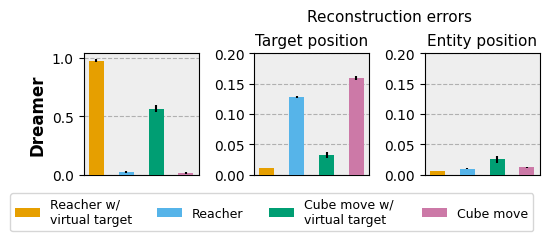

In [10]:
# PLOT RECONSTRUCTION ERRORS
from utils import colors
columns = len(recon_error_metrics[models_id[0]].keys())
fig, axs = plt.subplots(1, columns, figsize=(5.5, 2.1))
x = np.arange(len(recon_error_metrics[models_id[0]]["target"].keys())) 

task2label = {"reacher_easy": "Reacher", "reacher_easy_vis_target": "Reacher w/ \nvirtual target", "CustomLift": "Cube move", "CustomLift_vis_target": "Cube move w/ \nvirtual target"}

model_id = "2"
if "proprio" in recon_error_metrics[model_id].keys(): del recon_error_metrics[model_id]["proprio"]
    
for t, task in enumerate(recon_error_metrics[model_id]["target"].keys()):
    for i, metric in enumerate(recon_error_metrics[model_id].keys()):
        
        ax = axs[i]
        if metric == "success_rate":
            ax.set_ylabel("Dreamer", fontsize=12, fontweight='heavy') if model_id == "2" else ax.set_ylabel("FOCUS", fontsize=12, fontweight='heavy')
        if metric == "objects_pos":
            ax.set_title("Entity position", fontsize=11)
        elif metric == "target":
            ax.set_title("Target position", fontsize=11)
            
            # ax.set_title(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=11)
        ax.set_facecolor('#eeeeee')
        ax.grid(visible=True, which='major', axis='y', linestyle='--', zorder=0)
        if metric in ["target", "objects_pos"]:
            ax.set_ylim(0, 0.2)
        
        ax.set_xticks([])
        try:
            # ax.bar(x[t], np.mean(recon_error_metrics[model_id][metric][task]["mean"][recon_error_metrics[model_id][metric][task]["mean"] < 1]), yerr = np.mean(recon_error_metrics[model_id][metric][task]["std"][recon_error_metrics[model_id][metric][task]["mean"] < 1]), label=task2label[task], color=colors()[t], zorder=3)
            ax.bar(x[t], np.mean(recon_error_metrics[model_id][metric][task]["mean"]), yerr = np.mean(recon_error_metrics[model_id][metric][task]["std"]), label=task2label[task], color=colors()[t], zorder=3, width=0.5)
        except:
            continue
fig.suptitle("Reconstruction errors", fontsize=11, x = .7, y=.9)
# fig.subplots_adjust(top=1, right=0.5, wspace=0.3)
fig.tight_layout()
ax.legend(ncol=4, bbox_to_anchor=(1,-0.1), fontsize=9)
plt.savefig(f"notebooks/focus++ evaluations/reconstructions_{model_id}.png", bbox_inches='tight', dpi=800)

In [31]:
from env.make import make

action_repeat = 2
models[benchmarks[0]][0].cfg.env.target_ablation_diam = False

eval_env = make(task2domain[task], task, action_repeat=action_repeat, seed=0, env_config=models[benchmarks[0]][0].cfg.env)

In [5]:
import collections

def flatten_observation(observation, output_key='observations'):
  if not isinstance(observation, collections.abc.MutableMapping):
    raise ValueError('Can only flatten dict-like observations.')

  if isinstance(observation, collections.OrderedDict):
    keys = observation.keys()
  else:
    # Keep a consistent ordering for other mappings.
    keys = sorted(observation.keys())

  observation_arrays = [observation[key].ravel() for key in keys]
  return type(observation)([(output_key, np.concatenate(observation_arrays))])

def get_target_observation(goal_pose):
    
    eval_env.set_goal_state(goal_pose) 
    action = np.zeros_like(eval_env.act_space["action"].sample())   
    obs = eval_env.step(action)
    return obs

In [32]:
import utils

# Initialization
step = ep = total_reward = total_success = global_step = 0

In [11]:
def det(t):
    return t.detach().cpu().numpy()

def mean_std(t):
    if isinstance(t, torch.Tensor):
        t = det(t)
        
    mean = np.nanmean(np.where(np.isclose(t,0, atol=1e-2), np.nan, t), axis=tuple(np.arange(2, len(t.shape)))) # TODO some values are set to nan, might be an issue with the denominator, need to be at least at 1
    std = np.nanstd(np.where(np.isclose(t,0, atol=1e-2), np.nan, t), ddof=1, axis=tuple(np.arange(2, len(t.shape))))
    stderr = std / np.sqrt(np.prod(t.shape[2:]) - np.isnan(np.where(np.isclose(t,0, atol=1e-2), np.nan, t)).sum(axis=tuple(np.arange(2, len(t.shape)))))
    return mean, std, stderr

def merge_rgb_layers(data, seg):
    merged = torch.zeros((list(data.shape)[:2] + list(data.shape)[3:]), device=data.device)
    for instance in range(data.shape[2]):
        # seg_channel = seg[:,:,instance].unsqueeze(2)
        merged = merged + data[:,:,instance] # * seg_channel.repeat(1, 1, 3, 1, 1)
    return merged

def assign_to_metrics(key, benchmark, mean, std):
    for i, s in enumerate(error_steps):
        metrics[key][benchmark][i]["mean"] += mean[0, s] / num_episodes / seeds
        metrics[key][benchmark][i]["std"] += std[0, s] / num_episodes / seeds

# get all the models for a given task and compute metrics like object position reconstruction

num_episodes = 10
seeds = 3

metrics = {k: {id: [{"mean": 0, "std": 0} for _ in range(len(error_steps))] for id in models.keys()} for k,v in metrics.items()}
recons_input = "objects_pos"

# for each model compute the different metrics and plot them in the graph
for benchmark, model_seeds in models.items():
    print(benchmark)
    # if benchmark != "offline_rs_benchmark_5": continue
    
    for r_i, model in enumerate(model_seeds):
        for episode in tqdm(episodes[task][:num_episodes]):
            agent = model
            data = agent.wm.preprocess(episode)
            truth = data[recons_input] + 0.5 if recons_input=="rgb" else data[recons_input]
            
            with torch.no_grad():
                # initialize latent state for each observation, fake zero action
                decoder_head = "object_decoder" if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"] else "decoder"
                decoder = agent.wm.heads[decoder_head] # B, T, C, H, W
                embed = agent.wm.encoder(data)
                
                post, prior = agent.wm.rssm.observe(
                    embed,
                    data["action"],
                    data["is_first"],
                )
                try:
                    recon = decoder(agent.wm.rssm.get_feat(post), masks=data["segmentation"])[recons_input].mean
                except:
                    continue
                if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"]: recon = merge_rgb_layers(recon, data["segmentation"]) # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
                recon += 0.5
                
                # post_recons[task][id] = recon
                init = {k: v[:, imag_start_step] for k, v in post.items()}
                # mse errors in the predictions
                pred_prior = agent.wm.rssm.imagine(data["action"][:, imag_start_step+1:], init)
                seg = data["segmentation"][:, imag_start_step+1:]
                
                prior_recon = decoder(agent.wm.rssm.get_feat(pred_prior), masks=seg)[recons_input].mean
                if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"]: prior_recon = merge_rgb_layers(prior_recon, seg)  # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
                prior_recon += 0.5
                
                # prior_recons[task][id] = prior_recon
                
                prior_error = torch.abs(agent.wm.rssm.get_feat(pred_prior) - agent.wm.rssm.get_feat(prior)[:, imag_start_step+1:]) #TODO try with respect to the posterior output
                
                mean, _, std = mean_std(prior_error)
                assign_to_metrics("prior_error", benchmark, mean, std)
                
                prior_recon_error = torch.abs((prior_recon) - truth[:, imag_start_step+1:])
                
                mean, _, std = mean_std(prior_recon_error)
                assign_to_metrics("prior_recon_error", benchmark, mean, std)
                                    
                # mse objects errors in the predictions
                # Mask of object -> dilate mask -> compute mse over selected region
                # if "segmentation" in data.keys():
                #     seg = data["segmentation"][:,:,0]
                #     struct = np.array([[[[0, 1, 0], [1, 1, 1], [0, 1, 0]]]])
                #     dilated_seg = ndimage.binary_dilation(det(seg), struct, iterations=2)
                #     dilated_seg_rgb_axis = np.repeat(dilated_seg[:, :, np.newaxis], 3, axis=2)
                    
                #     truth_masked = det(truth) * dilated_seg_rgb_axis
                #     recon_masked = det(recon) * dilated_seg_rgb_axis
                    
                #     prior_recon_masked = det(prior_recon) * dilated_seg_rgb_axis[:,imag_start_step+1:]
                #     # prior_recons_masked[task][id] = prior_recon_masked

                #     recon_masked_error = np.abs(truth_masked - recon_masked)  # mean over the mask
                #     # recon_masked_metrics = {"mean": np.sum(recon_masked_error) / (np.sum(dilated_seg_rgb_axis)) ,"std": np.nanstd(np.where(np.equal(recon_masked_error,0), np.nan, prior_recon_masked_error))}
                #     mean, _, std = mean_std(recon_masked_error)
                #     assign_to_metrics("recon_masked_error", benchmark, mean, std)     
                            
                #     prior_recon_masked_error = np.abs(truth_masked[:,imag_start_step+1:] - prior_recon_masked)  # mean over the mask
                #     # prior_recon_masked_metrics = {"mean": np.sum(prior_recon_masked_error) / (np.sum(dilated_seg_rgb_axis)) ,"std": np.nanstd(np.where(np.equal(prior_recon_masked_error,0), np.nan, prior_recon_masked_error))}
                #     mean, _, std = mean_std(prior_recon_masked_error)
                #     assign_to_metrics("prior_recon_masked_error", benchmark, mean, std)                 

offline_rs_benchmark_1


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


offline_rs_benchmark_2


100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


...

100%|██████████| 10/10 [00:03<00:00,  3.30it/s]


offline_rs_benchmark_4_temporal


100%|██████████| 10/10 [00:03<00:00,  3.30it/s]


offline_rs_benchmark_5


100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


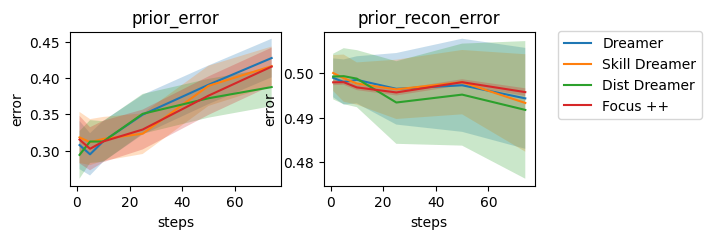

In [38]:
benchmark2agent = {"1": "Dreamer", "2": "Skill Dreamer", "3": "Dist Dreamer", "4_cosine": "LEXA Cosine", "4_temporal": "LEXA Temporal", "5": "Focus ++"}

# get plot initiated for the metrics
n_models = len(benchmark2agent.keys())
n_metrics = len(metrics.keys())
fig, axs = plt.subplots(1, n_metrics, figsize=(n_metrics*3, 2))

for i, (metric, values) in enumerate(metrics.items()):
    for j, (benchmark, values) in enumerate(values.items()):
        if benchmark in ["offline_rs_benchmark_4_cosine", "offline_rs_benchmark_4_temporal"]:
            continue
        ax = axs[i]
        means = [v["mean"] for v in values]
        stds = [v["std"] for v in values]
        ax.plot(error_steps, means, label=benchmark2agent["_".join(benchmark.split("_")[3:])])
        ax.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
        ax.set_title(metric)
        ax.set_xlabel("steps")
        ax.set_ylabel("error")

ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(1.45,1.05))

In [27]:
n_pos = 100
object_test_poses = np.random.uniform([-0.25,-0.25,0.001], [0.25,0.25,0.001], (n_pos, 3))
print(object_test_poses)

[[    0.22438   -0.039335       0.001]
 [    0.12732   -0.093111       0.001]
 [    0.18099   -0.065693       0.001]
 [  -0.023128    -0.20373       0.001]
 [    0.13871     0.22131       0.001]
 [   0.070024     0.17812       0.001]
 [    0.21809   -0.057026       0.001]
 [   0.014844     0.18498       0.001]
 [   -0.15937    0.081245       0.001]
 [   -0.15966    0.028134       0.001]
 [    0.17335    0.035315       0.001]
 [    0.12419     0.24189       0.001]
 [    0.21171    -0.10852       0.001]
 [    0.08468    -0.17656       0.001]
 [    0.23711    -0.11475       0.001]
 [    -0.2435    0.016673       0.001]
 [   -0.15879    0.029007       0.001]
 [   -0.16432    0.041103       0.001]
 [   0.036997    -0.15622       0.001]
 [   -0.11485   -0.075849       0.001]
 [   -0.21629     0.04284       0.001]
 [   -0.07629    -0.09028       0.001]
 [    0.19406     0.15468       0.001]
 [    0.22055      0.2329       0.001]
 [    0.14296      0.1091       0.001]
 [  -0.014393   -0.027459

In [76]:
# Individual episode analysis
# usign online generated steps, have the keep the observation fixed and obtain the reconstruction image, check if there is a correlation between the objects_pos 
# and the object in the scene
def merge_rgb_layers(data, seg):
    merged = torch.zeros((list(data.shape)[:2] + list(data.shape)[3:]), device=data.device)
    for instance in range(data.shape[2]):
        # seg_channel = seg[:,:,instance].unsqueeze(2)
        merged = merged + data[:,:,instance] # * seg_channel.repeat(1, 1, 3, 1, 1)
    return merged

benchmark = "offline_rs_benchmark_1"
if benchmark == "offline_rs_benchmark_3": eval_env.dist_as_rw = True 
else: eval_env.dist_as_rw = False

recons_input = "proprio"
plotting = False

model = models[benchmark][0]
obs = eval_env.reset()
orig_obj_pos = obs["objects_pos"]
print("Original obejct position: ", obs["objects_pos"])
# generate random positions (fixed and plot errors in the reconstruction for different models) 
# object_test_poses = [[ -0.25, -0.25, 0.001], [ 0.25, 0.25, 0.001], [ 0.25, -0.25, 0.001], [ -0.25, 0.25, 0.001]]
if plotting: fig, axs = plt.subplots(1, len(object_test_poses) + 1, figsize=(10, 5))

agent = model
if plotting: axs[0].imshow(obs["rgb"].transpose(1,2,0))
cumm_error = 0

for i, object_test_pose in enumerate(object_test_poses):
    # obs["objects_pos"] = np.array([object_test_pose], dtype=np.float32)
    # obs["rgb"] = eval_env.set_goal_state(object_test_pose)["rgb"]
    # TODO: change the target position to the object_test_pose, generate observation with the object at the target location, check if the reward is assigned properly.
    
    eval_env.set_target(object_test_pose)
    object_to_target = obs["objects_pos"] - object_test_pose
    obs["proprio"][-3:] = object_to_target
    obs["reward"] = - np.linalg.norm(object_to_target)
    
    tensor_obs = {k: torch.as_tensor(np.copy(v), device="cuda:0").unsqueeze(0).unsqueeze(0) for k, v in obs.items()} # tensorize the observation
    data = agent.wm.preprocess(tensor_obs)
    truth = data[recons_input] + 0.5 if recons_input=="rgb" else data[recons_input]
    with torch.no_grad():
        # initialize latent state for each observation, fake zero action
        decoder_head = "object_decoder" if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"] else "decoder"
        # decoder_head = "reward"
        decoder = agent.wm.heads[decoder_head] # B, T, C, H, W
        
        embed = agent.wm.encoder(data) # encode observation
    
        post, prior = agent.wm.rssm.observe(
            embed,
            data["action"],
            data["is_first"],
        )
        
        recon = decoder(agent.wm.rssm.get_feat(post), masks=data["segmentation"])
        proprio_recon = recon["proprio"].mean

        if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"]: rgb_recon = merge_rgb_layers(rgb_recon, data["segmentation"]) # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
        # rgb_recon += 0.5

    if plotting: axs[i+1].imshow(rgb_recon[0,0].cpu().numpy().transpose(1,2,0))
    
    truth = obs["proprio"][-3:]
    print(f"Truth: {truth} - Reconstruction: {proprio_recon[..., -3:]}")
    # cumm_error += np.linalg.norm(recon["objects_pos"].mean.cpu().numpy() - orig_obj_pos) / n_pos
    cumm_error += np.linalg.norm(proprio_recon[..., -3:].cpu().numpy() - truth) / n_pos
    

    # # post_recons[task][id] = recon
    # init = {k: v[:, imag_start_step] for k, v in post.items()}
    # # mse errors in the predictions
    # pred_prior = agent.wm.rssm.imagine(data["action"][:, imag_start_step+1:], init)
    # seg = data["segmentation"][:, imag_start_step+1:]
    
    # prior_recon = decoder(agent.wm.rssm.get_feat(pred_prior), masks=seg)[recons_input].mean
    # if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"]: prior_recon = merge_rgb_layers(prior_recon, seg)  # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
    # prior_recon += 0.5
    
    # # prior_recons[task][id] = prior_recon
    
    # prior_error = torch.abs(agent.wm.rssm.get_feat(pred_prior) - agent.wm.rssm.get_feat(prior)[:, imag_start_step+1:]) #TODO try with respect to the posterior output
    
    # mean, _, std = mean_std(prior_error)
    # assign_to_metrics("prior_error", benchmark, mean, std)
    
    # prior_recon_error = torch.abs((prior_recon) - truth[:, imag_start_step+1:])
    
    # mean, _, std = mean_std(prior_recon_error)
    # assign_to_metrics("prior_recon_error", benchmark, mean, std)
    
print(f"{benchmark} - error pos reconstruction: {cumm_error}")


Original obejct position:  [[ -0.0088552   -0.011673       0.001]]
Truth: [     0.1526    0.091549  4.7497e-11] - Reconstruction: tensor([[[-0.0035,  0.0060, -0.0494]]], device='cuda:0')
Truth: [  -0.046992     0.13285  4.7497e-11] - Reconstruction: tensor([[[-0.0235,  0.0068, -0.0370]]], device='cuda:0')
Truth: [   0.025739     -0.1276  4.7497e-11] - Reconstruction: tensor([[[-0.0390,  0.0083, -0.0543]]], device='cuda:0')
Truth: [    0.22279    -0.16996  4.7497e-11] - Reconstruction: tensor([[[-0.0205,  0.0053, -0.0470]]], device='cuda:0')
Truth: [    -0.1886    0.089059  4.7497e-11] - Reconstruction: tensor([[[-0.0308, -0.0070, -0.0578]]], device='cuda:0')
Truth: [   0.026753    0.039619  4.7497e-11] - Reconstruction: tensor([[[-0.0270,  0.0002, -0.0543]]], device='cuda:0')
Truth: [   0.018895    0.032341  4.7497e-11] - Reconstruction: tensor([[[-0.0241,  0.0011, -0.0421]]], device='cuda:0')
Truth: [    -0.1264    0.042519  4.7497e-11] - Reconstruction: tensor([[[-0.0413,  0.0160, -0

In [67]:
proprio_recon.shape

torch.Size([1, 1, 35])

In [35]:
# Individual episode analysis
# usign online generated steps, have the keep the observation fixed and obtain the reconstruction image, check if there is a correlation between the objects_pos 
# and the object in the scene
n_pos = 100
object_test_poses = np.random.uniform([-0.25,-0.25], [0.25,0.25], (n_pos, 2))

def merge_rgb_layers(data, seg):
    merged = torch.zeros((list(data.shape)[:2] + list(data.shape)[3:]), device=data.device)
    for instance in range(data.shape[2]):
        # seg_channel = seg[:,:,instance].unsqueeze(2)
        merged = merged + data[:,:,instance] # * seg_channel.repeat(1, 1, 3, 1, 1)
    return merged

benchmark = "offline_reacher_benchmark_5"
if benchmark == "offline_reacher_benchmark_3": eval_env.dist_as_rw = True 
else: eval_env.dist_as_rw = False

recons_input = "rgb"
plotting = False

model = models[benchmark][0]
obs = eval_env.reset()
orig_obj_pos = obs["objects_pos"]
print("Original obejct position: ", obs["objects_pos"])
# generate random positions (fixed and plot errors in the reconstruction for different models) 
# object_test_poses = [[ -0.25, -0.25, 0.001], [ 0.25, 0.25, 0.001], [ 0.25, -0.25, 0.001], [ -0.25, 0.25, 0.001]]
if plotting: fig, axs = plt.subplots(1, len(object_test_poses) + 1, figsize=(10, 5))

agent = model
if plotting: axs[0].imshow(obs["rgb"].transpose(1,2,0))
cumm_error = 0

for i, object_test_pose in enumerate(object_test_poses):
    # obs["objects_pos"] = np.array([object_test_pose], dtype=np.float32)
    # obs["rgb"] = eval_env.set_goal_state(object_test_pose)["rgb"]
    # TODO: change the target position to the object_test_pose, generate observation with the object at the target location, check if the reward is assigned properly.
    
    eval_env.set_target(object_test_pose)
    # object_to_target = obs["objects_pos"] - object_test_pose
    # obs["proprio"][2:4] = object_to_target
    # obs["reward"] = - np.linalg.norm(object_to_target)
    obs = eval_env.set_goal_state(object_test_pose)
    
    tensor_obs = {k: torch.as_tensor(np.copy(v), device="cuda:0").unsqueeze(0).unsqueeze(0) for k, v in obs.items()} # tensorize the observation
    data = agent.wm.preprocess(tensor_obs)
    truth = data[recons_input] + 0.5 if recons_input=="rgb" else data[recons_input]
    with torch.no_grad():
        # initialize latent state for each observation, fake zero action
        decoder_head = "object_decoder" if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"] else "decoder"
        # decoder_head = "reward"
        decoder = agent.wm.heads[decoder_head] # B, T, C, H, W
        
        embed = agent.wm.encoder(data) # encode observation
    
        post, prior = agent.wm.rssm.observe(
            embed,
            data["action"],
            data["is_first"],
        )
        
        recon = decoder(agent.wm.rssm.get_feat(post))#, masks=data["segmentation"])
        proprio_recon = recon["proprio"].mean

        if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"]: rgb_recon = merge_rgb_layers(rgb_recon, data["segmentation"]) # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
        # rgb_recon += 0.5

    if plotting: axs[i+1].imshow(rgb_recon[0,0].cpu().numpy().transpose(1,2,0))
    
    truth = obs["proprio"][2:4]
    print(f"Truth: {truth} - Reconstruction: {proprio_recon[..., 2:4]}")
    # cumm_error += np.linalg.norm(recon["objects_pos"].mean.cpu().numpy() - orig_obj_pos) / n_pos
    cumm_error += np.linalg.norm(proprio_recon[..., 2:4].cpu().numpy() - truth) / n_pos
    

    # # post_recons[task][id] = recon
    # init = {k: v[:, imag_start_step] for k, v in post.items()}
    # # mse errors in the predictions
    # pred_prior = agent.wm.rssm.imagine(data["action"][:, imag_start_step+1:], init)
    # seg = data["segmentation"][:, imag_start_step+1:]
    
    # prior_recon = decoder(agent.wm.rssm.get_feat(pred_prior), masks=seg)[recons_input].mean
    # if benchmark=="offline_rs_benchmark_5" and recons_input in ["rgb", "objects_pos"]: prior_recon = merge_rgb_layers(prior_recon, seg)  # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
    # prior_recon += 0.5
    
    # # prior_recons[task][id] = prior_recon
    
    # prior_error = torch.abs(agent.wm.rssm.get_feat(pred_prior) - agent.wm.rssm.get_feat(prior)[:, imag_start_step+1:]) #TODO try with respect to the posterior output
    
    # mean, _, std = mean_std(prior_error)
    # assign_to_metrics("prior_error", benchmark, mean, std)
    
    # prior_recon_error = torch.abs((prior_recon) - truth[:, imag_start_step+1:])
    
    # mean, _, std = mean_std(prior_recon_error)
    # assign_to_metrics("prior_recon_error", benchmark, mean, std)
    
print(f"{benchmark} - error pos reconstruction: {cumm_error}")

Original obejct position:  [[     -0.193        0.12]]
Truth: [  0.0048856    -0.18918] - Reconstruction: tensor([[[-0.1217,  0.0025]]], device='cuda:0')
Truth: [    -0.4209    0.086349] - Reconstruction: tensor([[[ 0.1609, -0.0072]]], device='cuda:0')
Truth: [   -0.16986    -0.15452] - Reconstruction: tensor([[[-0.0744,  0.0369]]], device='cuda:0')
Truth: [   0.022098     0.14837] - Reconstruction: tensor([[[-0.1426,  0.0121]]], device='cuda:0')
Truth: [   -0.45114   -0.021617] - Reconstruction: tensor([[[-0.1163,  0.0731]]], device='cuda:0')
Truth: [  -0.048268   -0.084828] - Reconstruction: tensor([[[-0.0595,  0.0217]]], device='cuda:0')
Truth: [    -0.4682    0.088307] - Reconstruction: tensor([[[-0.1376,  0.0319]]], device='cuda:0')
Truth: [   -0.42855      0.1962] - Reconstruction: tensor([[[-0.1284,  0.0464]]], device='cuda:0')
Truth: [   -0.41797     -0.1216] - Reconstruction: tensor([[[-0.1159,  0.0556]]], device='cuda:0')
Truth: [   -0.29028   -0.076577] - Reconstruction: ten

In [11]:
print(obs["proprio"])

[    0.23462   -0.084106 -0.00073362       -0.13           0           0]
